# The Cramér-Lundberg modelling of risk in non-life insurance




The Cramér-Lundberg model is a foundational mathematical framework used primarily in actuarial science and quantitative risk management. 
It is specifically designed to model the "surplus" or "wealth" process of an insurance company over time.The model is useful in several key areas of the insurance industry. It helps insurers determine the probability of ruin: "the scenario where claims exceed the company's available capital ($R_t < 0$)".



## Model Overview
In this section, we analyze the wealth of an insurance company modeled as a jump process. The wealth at time $t$, denoted by $R_t$, is defined by the following equation:

$$R_{t}=u+pt-\sum_{i=1}^{N_{t}}Y_{i}$$

### Model Parameters:
**$u \ge 0$**: The initial capital of the company.

**$p > 0$**: The premium rate collected per unit of time.

**$N = (N_t)_{t \ge 0}$**: A homogeneous Poisson process with intensity $\mu > 0$ representing the number of claims.

**$(Y_i)_{i \ge 1}$**: A sequence of independent and identically distributed (iid) positive random variables representing the amount of each claim.

**$m = \mathbb{E}[Y_1]$**: The expected value of a claim, assumed to be finite.

In [9]:
def simulation_richesse(mu,T,beta,u,n,theta):
    p=(1+theta)*mu*1/beta
    Nt=np.random.poisson(mu*T,1)[0]
    temps_arrivee=np.random.uniform(0,T,Nt)
    temps_arrivee=np.sort(temps_arrivee)
    Y=np.random.exponential(1/beta,Nt)
    t=np.arange(0,T,1/n)
    Rt = np.zeros(len(t))
    
    for idx, ti in enumerate(t):
        mask = temps_arrivee <= ti  # sinistres survenus avant ti
        if mask.sum() > 0:
            somme = np.sum(Y[mask])
        else:
            somme = 0
        Rt[idx] = u + p * ti - somme
    return (t,Rt)

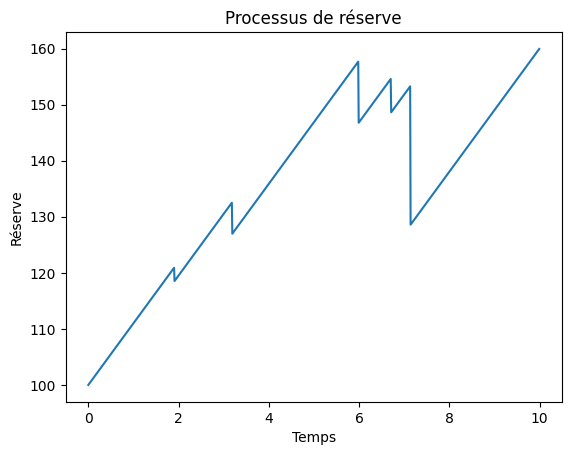

In [ ]:
mu=1
T=10
beta=0.1
theta=0.1
n=100
u=100
t,Rt=simulation_richesse(mu,T,beta,u,n,theta)
plt.plot(t,Rt)
plt.title("Wealth process")
plt.xlabel("Time")
plt.ylabel("wealth")
plt.show()

## Study Objectives
The risk analysis focuses on two main axes:

### 1. Profitability Condition
We aim to determine the critical premium rate value, denoted as $p^*$, such that for any $p > p^*$, the expected wealth $\mathbb{E}[R_t]$ remains strictly positive for all $t$. This ensures the company is structurally profitable.



1) To determine the expected wealth at time $t$, we use the linearity of expectation and the properties of the compound Poisson process
$\mathbb{E}[R_{t}] = \mathbb{E}[u + pt] - \mathbb{E}\left[\sum_{i=1}^{N_{t}} Y_{i}\right]$. Since $u$ and $p$ are constant parameters, $\mathbb{E}[u + pt] = u + pt$. Compound Poisson Process: According to Wald's identity, the expectation of a random sum where $N_t$ follows a Poisson process with parameter $\mu t$ and the $(Y_i)$ are iid with mean $m$ is given by:
$$\mathbb{E}\left[\sum_{i=1}^{N_{t}} Y_{i}\right] = \mathbb{E}[N_t] \cdot \mathbb{E}[Y_1] = \mu t \cdot m$$ Result: The explicit form of the expected wealth at any time $t$ is:$$\mathbb{E}[R_{t}] = u + (p - \mu m)t$$
2) We are looking for the value $p^*$ such that for any $p > p^*$, the expected wealth remains strictly positive for any time $t \ge 0$. Based on the formula established previously:$$\mathbb{E}[R_{t}] = u + t(p - \mu m)$$For this value to remain strictly positive regardless of $t$ (particularly as $t \to +\infty$), the slope of the line must be strictly positive or zero, provided that the initial capital $u$ ensures positivity at $t=0$. Since $u \ge 0$, the condition $\mathbb{E}[R_{t}] > 0$ for any $t$ requires the drift of the process to be positive: $p - \mu m > 0$. From this, we derive the critical value $p^*$:$$p^* = \mu m$$

### 2. Ruin Probability (Approximation)
The regulator is interested in the probability that the company goes bankrupt during the contract period. We study a simplified version of ruin at horizon $T$, defined by the Bernoulli random variable $\mathcal{R}$:
$$\{\mathcal{R}=1\} \Leftrightarrow \{R_{T} < 0\}$$

The goal is to analyze the impact of the initial capital $u$ on this probability $\mathbb{P}[\mathcal{R}=1]$ using **Monte-Carlo** simulations.

## Simulation Parameters
For the numerical applications, the following values are fixed:
**Time Horizon**: $T = 100$ 
**Intensity**: $\mu = 1$ 
**Claim Distribution**: $Y_i \sim \mathcal{E}(\beta)$ with $\beta = 0.1$ 
***Premium Rate**: $p = (1+\theta)p^*$ with a safety loading $\theta = 30\%$ 

In [2]:
!pip install numpy
!pip install matplotlib

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
##"Estimation of Rt"
def estimation_ruine(mu,T,beta,u,theta,n) :
    nb_ruine=0
    p=(1+theta)*mu*1/beta
    for i in range (n) :
        
        Nt=np.random.poisson(mu*T,1)[0]
        temps_arrivee=np.random.uniform(0,T,Nt)
        temps_arrivee=np.sort(temps_arrivee)
        #print(Nt)
        #print(temps_arrivee)
        Y=np.random.exponential(1/beta,Nt)
        #print(Y)
        sinistres=np.cumsum(Y)
        #print(sinistres)
        for j in range(Nt):
            if u+p*temps_arrivee[j]-sinistres[j]<=0 :
                nb_ruine+=1
                break
    return nb_ruine/n

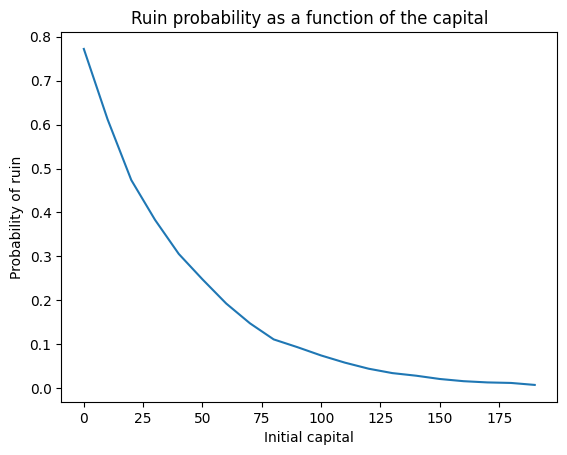

In [5]:
##"Ruin probability as a function of the capital"
mu=1
T=100
beta=0.1
theta=0.3
n=10000
proba_ruine=np.zeros(20)
u=np.zeros(20)
for k in range(20):
    u[k]=10*k
    proba_ruine[k]=estimation_ruine(mu,T,beta,u[k],theta,n)

plt.plot(u,proba_ruine)
plt.title("Ruin probability as a function of the capital")
plt.xlabel("Initial capital")
plt.ylabel("Probability of ruin")
plt.show()

-0.028456027971605583


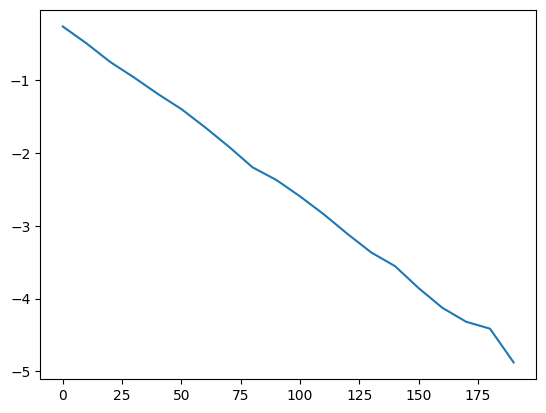

In [6]:
##"Estimation of k"
log_proba_ruine=np.log(proba_ruine)
plt.plot(u,log_proba_ruine)
kappa=np.mean(log_proba_ruine[1:20]/u[1:20])
print(kappa)

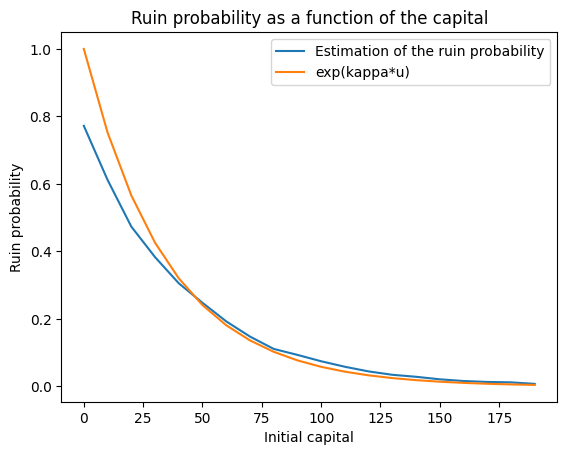

In [8]:
##"Comaparaison Estimation and exponential model "
plt.plot(u,proba_ruine,label="Estimation of the ruin probability")
plt.plot(u,np.exp(kappa*u),label="exp(kappa*u)")
plt.title("Ruin probability as a function of the capital")
plt.xlabel("Initial capital")
plt.ylabel("Ruin probability")
plt.legend()
plt.show()